## Differential Evolution

In this session, we will discover how Differential Evolution (DE) works. We will explore the underlying principles, implement core components from scratch, apply DE to classic benchmark functions, visualize its dynamics through a generated GIF, and tackle constraints.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.collections import PathCollection
from typing import Callable
from dataclasses import dataclass

### Optimization Problems

This cell defines three common benchmark functions, Sphere, Rosenbrock, and Rastrigin, used to test optimization algorithms. We also used these functions earlier to evaluate Adam, Momentum, and CMA-ES.

In [2]:
def sphere(x: np.ndarray) -> float:
    return float(np.sum(x**2))


def rosenbrock(x: np.ndarray) -> float:
    return float(np.sum(100.0 * (x[1:] - x[:-1] ** 2.0) ** 2.0 + (1.0 - x[:-1]) ** 2.0))


def rastrigin(x: np.ndarray) -> float:
    A: float = 10.0
    return float(A * len(x) + np.sum(x**2 - A * np.cos(2 * np.pi * x)))

BOUNDS = [(-5, 5), (-5, 5)]

### Differential Evolution

Differential Evolution is a simple yet powerful **population-based search algorithm** for continuous optimization. At every iteration it maintains a population of $pop\_size$ candidate solutions, each an $n$-dimensional real-valued vector. Three straightforward operators: mutation, crossover, and selection, are applied to push the population toward regions of lower objective value.

#### 1. Initialisation  
Randomly sample $pop\_size$ vectors inside the problem's bounds.

#### 2. Mutation  
For each target vector $x_i$:

1. Select three distinct solutions $a$, $b$, $c$ (none equal to $x_i$) from current population.  
2. Create the mutant  
   $$v = a + F\,(b - c)$$
   where $F \in (0.4,1^+)$ is the scaling factor. The difference $(b-c)$ supplies direction and scale; $F$ stretches or shrinks the step.

#### 3. Crossover  
Blend the mutant $v$ with its target $x_i$ to form the trial vector \(u\):

- For each coordinate $j$, copy $v_j$ into $u_j$ with probability $CR$; otherwise copy $x_{i,j}$.  
- Force at least one coordinate to come from $v$ so that $u \neq x_i$.

Here $CR \in [0,1]$ is the *crossover rate*: higher $CR$ means aggressive mixing; lower $CR$ leaves the mutant mostly intact.

#### 4. Selection  
Evaluate the objective $f(\cdot)$: $u \text{ replaces } x_i \quad \text{if} \quad f(u) < f(x_i)$

Greedy replacement ensures the population does not deteriorate.

#### 5. Iteration & Termination  
After every target has produced a trial and selection is done, the new population is complete. Repeat until a generation limit, a fitness threshold, or a stall criterion is reached.

#### 6. Parameter intuition  

| Parameter | Typical range |
|-----------|---------------|
| Differential weight \(F\) | 0.4 – 1.0 |
| Crossover rate \(CR\)     | 0.1 – 0.9 |
| Population size \(P\)     | $5n$ – $10n$ |

In [5]:
@dataclass
class DEResult:
    best_vector: np.ndarray
    best_value: float
    history: list[np.ndarray] # History of populations for animation
    fitness_history: list[float] # History of best fitness values for plotting


def differential_evolution(
    func: Callable[[np.ndarray], float],
    bounds: list[tuple[float, float]] = BOUNDS,
    pop_size: int = 50,
    F: float = 0.8,
    CR: float = 0.9,
    max_gen: int = 100,
    seed: int | None = None,
) -> DEResult:
    """
    Implements the Differential Evolution algorithm for global optimization.

    Parameters:
        func: Objective function to minimize. Takes a numpy array and returns a float.
        bounds: list of (min, max) pairs for each dimension.
        pop_size: Number of individuals in the population.
        F: Mutation factor (typically in [0.4, 1.0]).
        CR: Crossover rate (typically in [0, 1]).
        max_gen: Maximum number of generations to evolve.
        seed: Optional RNG seed for reproducible runs.
    """
    np.random.seed(seed)
    dimensions = len(bounds)
    lower_bounds = np.array([b[0] for b in bounds])
    upper_bounds = np.array([b[1] for b in bounds])
    
    # --- TODO: Exercise 1 - Initialization ---
    # Initialize the population: Create pop_size individuals.
    # Each individual is a vector of 'dimensions' length.
    # Use uniform distribution to sample the initial population.
    # --- End Exercise 1 ---

    population = np.random.uniform(lower_bounds, upper_bounds, size=(pop_size, dimensions))
    fitness = np.array([func(idx) for idx in population])

    best_idx = np.argmin(fitness)
    de_result = DEResult(
        best_vector=population[best_idx].copy(),
        best_value=fitness[best_idx],
        history=[population.copy()],
        fitness_history=[fitness[best_idx]],
    )
    
    for generation in range(max_gen):
        next_population = population.copy()
        next_fitness = fitness.copy()

        for i in range(pop_size):
            # --- TODO: Exercise 2 - Mutation ---
            # Select three distinct random individuals (a, b, c) from the population,
            # different from the current target_vector at index i.
            # Ensure indices are unique and not equal to i.
            # Create the mutant vector: v = a + F * (b - c)
            #
            # Boundary handling: the mutant may fall outside `bounds`. Use the
            # simplest strategy and clip each coordinate back into its
            # [lower, upper] range with `np.clip`.
            # --- End Exercise 2 ---
            indices = [idx for idx in range(pop_size) if idx != i]
            idxa, idxb, idxc = np.random.choice(indices, 3, replace=False)
            a = population[idxa]
            b = population[idxb]
            c = population[idxc]

            mutant_vector = a + F * (b - c)
            mutant_vector = np.clip(mutant_vector, lower_bounds, upper_bounds)
            
            # --- TODO: Exercise 3 - Crossover ---
            # Create the trial vector by performing crossover between the target_vector and the mutant_vector.
            # For each dimension j:
            #   Pick a random number r from [0,1).
            #   If r < CR or j == j_rand (where j_rand is a randomly chosen dimension index),
            #     trial_vector[j] = mutant_vector[j]
            #   Else:
            #     trial_vector[j] = target_vector[j]
            # Ensure at least one dimension comes from the mutant vector (j_rand ensures this).
            # --- End Exercise 3 ---
            target_vector = population[i]
            trial_vector = np.empty_like(target_vector)
            j_rand = np.random.randint(0, dimensions)
            for j in range(dimensions):
                r = np.random.rand()
                if r < CR or j == j_rand:
                    trial_vector[j] = mutant_vector[j]
                else:
                    trial_vector[j] = target_vector[j]
            
            # --- TODO: Exercise 4 - Selection ---
            # Evaluate the trial vector.
            # If the trial vector is better than or equal to the target vector,
            #   replace the target vector with the trial vector in the new_population and update its fitness.
            # Else, keep the target vector.
            # --- End Exercise 4 ---
            trial_fitness = func(trial_vector)
            if trial_fitness <= fitness[i]:
                next_population[i] = trial_vector
                next_fitness[i] = trial_fitness
                if trial_fitness < de_result.best_value:
                    de_result.best_vector = trial_vector.copy()
                    de_result.best_value = trial_fitness
        population = next_population
        fitness = next_fitness
        de_result.history.append(population.copy())
        de_result.fitness_history.append(de_result.best_value)
    return de_result

### Test implemented DE

In [6]:
result = differential_evolution(sphere, bounds=BOUNDS, pop_size=50)

### Visualizing Search Dynamics

In [7]:
def animate_de(
    func: Callable[[np.ndarray], float],
    history: list[np.ndarray],
    bounds: list[tuple[float, float]] = BOUNDS,
    frames: int | None = None,
    filename: str = "de_animation.gif",
) -> None:
    """
    Creates and saves a GIF showing how the DE population moves over generations.
    """
    if frames is None:
        frames = len(history)

    assert len(bounds) == 2, "This function only supports 2D visualization (expected 2 bounds)."
    x_bounds = (bounds[0][0], bounds[0][1])
    y_bounds = (bounds[1][0], bounds[1][1])

    x = np.linspace(x_bounds[0], x_bounds[1], 200)
    y = np.linspace(y_bounds[0], y_bounds[1], 200)
    X, Y = np.meshgrid(x, y)
    coords = np.vstack([X.ravel(), Y.ravel()]).T
    Z = np.array([func(pt) for pt in coords]).reshape(X.shape)

    fig, ax = plt.subplots(figsize=(8, 6))
    contour = ax.contourf(X, Y, Z, levels=20, cmap="viridis")
    fig.colorbar(contour, ax=ax)

    # Track only the scatters we add so we can remove them between frames
    # without touching the contour (works across matplotlib versions).
    scatters: list = []

    def update(i: int):
        while scatters:
            scatters.pop().remove()

        ax.set_title(f"Generation {i}")

        DECAY_CONSTANT = 10

        # Plot all generations up to i, with alpha decreasing for older points
        for j in range(i + 1):
            age = i - j
            alpha = float(np.exp(-age / DECAY_CONSTANT))
            pop_j = history[j]
            scatters.append(
                ax.scatter(pop_j[:, 0], pop_j[:, 1], s=24, color="red", edgecolors="none", alpha=alpha)
            )

        # Return an empty tuple since we're redrawing everything
        return ()

    ax.set_xlim(x_bounds[0], x_bounds[1])
    ax.set_ylim(y_bounds[0], y_bounds[1])

    anim = animation.FuncAnimation(
        fig,
        update,
        frames=frames,
        interval=200,
        blit=False,  # must be False since we redraw each frame
    )

    writer = animation.PillowWriter(fps=5)
    anim.save(filename, writer=writer)
    plt.close(fig)
    print(f"Animation saved to {filename}")

In [8]:
animate_de(func=sphere, history=result.history)

Animation saved to de_animation.gif


### Experiments
Run DE on all three problems: Sphere, Rosenbrock and Rastrigin. For each problem:
- Generate and analyze convergence plots showing the progression of the best fitness value over iterations.
- Visualize the population dynamics over time to illustrate how the search space is explored and exploited.

In [9]:
result_sphere = differential_evolution(sphere, bounds=BOUNDS, pop_size=50)
result_rosenbrock = differential_evolution(rosenbrock, bounds=BOUNDS, pop_size=50)
result_rastrigin = differential_evolution(rastrigin, bounds=BOUNDS, pop_size=50)

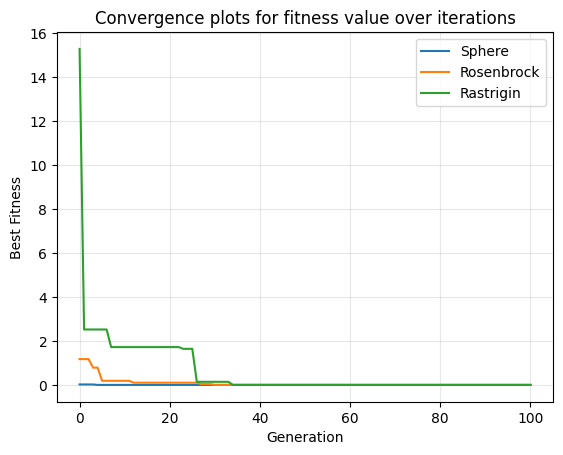

In [12]:
plt.plot(result_sphere.fitness_history, label="Sphere")
plt.plot(result_rosenbrock.fitness_history, label="Rosenbrock")
plt.plot(result_rastrigin.fitness_history, label="Rastrigin")

plt.xlabel("Generation")
plt.ylabel("Best Fitness")
plt.title("Convergence plots for fitness value over iterations")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Comments
We can see that the Sphere problem has the best convergence, Rosenbrock with wide valley is second and the hardest is Rastrigin to find the global optimum for function structure with many 'holes'.

In [11]:
animate_de(func=sphere, history=result_sphere.history, filename="sphere_de.gif")
animate_de(func=rosenbrock, history=result_rosenbrock.history, filename="rosenbrock_de.gif")
animate_de(func=rastrigin, history=result_rastrigin.history, filename="rastrigin_de.gif")

Animation saved to sphere_de.gif
Animation saved to rosenbrock_de.gif
Animation saved to rastrigin_de.gif


## Comments
On Sphere and Rosenbrock the next populations mutate quickly to be placed on the minimum and find the patterns of the function (they become circle shape placed on sphere chart and u-shaped on the Rosenbrock chart). For Rastrigin the population does not converge easily, exploring the space much more and at the end finding several potential spots for minima and choosing the middle one after around 100 generations. So on Rastrigin we need to check the gif progress much longer than for simpler functions.

### Hyperparameters in Differential Evolution

Two hyperparameters drive DE's exploration/exploitation tradeoff:

- **Scaling factor $F$** controls the magnitude of the differential mutation step. Large $F$ → big jumps (exploration); small $F$ → small refinements (exploitation).
- **Crossover rate $CR$** controls how much of the mutant ends up in the trial vector. Large $CR$ → aggressive mixing across coordinates; small $CR$ → trial mostly inherits the target.

#### Task: $F \times CR$ grid search on Rastrigin

Rastrigin is highly multimodal, so it is a good stress test for these knobs. Run a grid over

- $F \in \{0.3,\ 0.5,\ 0.7,\ 0.9\}$
- $CR \in \{0.1,\ 0.3,\ 0.5,\ 0.7,\ 0.9\}$

For each $(F, CR)$ pair, run DE **5 times** with different seeds on **10D Rastrigin** (`bounds = [(-5, 5)] * 10`, `pop_size = 50`, `max_gen = 200`) and record the best final fitness. Aggregate by mean across seeds.

**Deliverables**

1. A heatmap of mean best fitness over the $F \times CR$ grid (e.g. `plt.imshow` with annotated cells, or `seaborn.heatmap`).
2. A short written analysis (3–5 sentences):
   - Which region of the grid performs best, and why?
   - What happens at the extreme corners (low $F$ + low $CR$; high $F$ + high $CR$)?
   - How does the answer connect to the exploration/exploitation framing above?

In [13]:
Fs = [0.3, 0.5, 0.7, 0.9]
CRs = [0.1, 0.3, 0.5, 0.7, 0.9]
results  = []

results = np.zeros((len(Fs), len(CRs)))

for i, f in enumerate(Fs):
    for j, cr in enumerate(CRs):
        result = []

        for run in range(5):
            res = differential_evolution(
                rastrigin,
                bounds=[(-5, 5)] * 10,
                pop_size=50,
                F=f,
                CR=cr,
                max_gen=200,
                seed=42 + run
            )
            result.append(res.best_value)

        results[i, j] = np.mean(result)

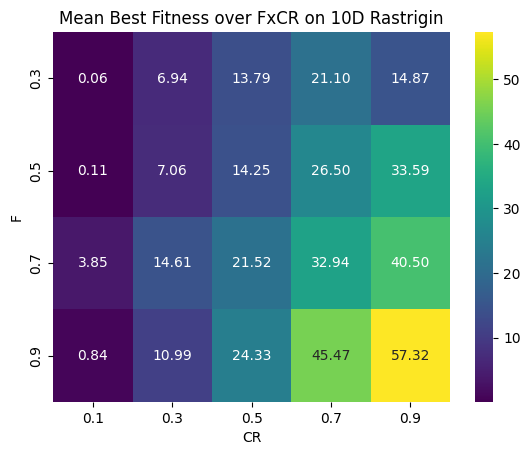

In [16]:
import seaborn as sns
sns.heatmap(results, annot=True, fmt=".2f", cmap="viridis",
            xticklabels=CRs, yticklabels=Fs)
plt.xlabel("CR")
plt.ylabel("F")
plt.title("Mean Best Fitness over FxCR on 10D Rastrigin")
plt.show()

## Comment
From the heatmanp, we can observe that the best fitness most valuable parameter for the Rastrigin problem is the CR parameter. With less aggresive mixing across coordinates, the model takes more conservative updates that preserve useful structure and reduce disruptive jumps. For the smalles `CR=0.1` we have the best fitness regardless the value of F and it is below 4. Especially it is the best for the smallest F. The corner case for smallest F and smallest CR (`F=0.3; C=0.1`) has the best performance on the Rastrigin problem. Rastrigin benefits more from cautious exploitation than from aggressive exploration.   
The bigger the F and CR, the worse fitness we obtain (the worst is on bottom right edge scenario).


### SHADE: Success-History Based Adaptive Differential Evolution

SHADE is an advanced variant of DE designed to enhance optimization performance through adaptive parameter control. Your task is to critically analyze the research paper [Success-History Based Parameter Adaptation for Differential Evolution](https://metahack.org/CEC2013-SHADE.pdf).
- Summarize the key concepts and mechanisms introduced in SHADE.
- Explain how SHADE differs from the standard DE algorithm.
- Discuss the motivation behind these changes and the empirical improvements demonstrated in the study.

## Comment
Answers to the questions:  
- SHADE keeps a memory of successful parameter values for F and CR, samples new values from that memory, and updates the memory using successful trials. It also uses a current-to-pbest mutation strategy and an external archive to maintain diversity.
- Standard DE usually uses fixed user-chosen F and CR, while SHADE adapts them automatically during the run based on past success.
- The goal is to make DE more robust across different landscapes by matching parameters to the problem state instead of forcing one setting everywhere. The paper reports that SHADE consistently outperforms classic DE and several adaptive variants on benchmark tests, especially on harder multimodal problems like Rastrigin.

### Recommended Reading
1. https://pablormier.github.io/2017/09/05/a-tutorial-on-differential-evolution-with-python/
2. Das, Swagatam, and Ponnuthurai Nagaratnam Suganthan. [Differential evolution: A survey of the state-of-the-art.](https://i2pc.es/coss/Docencia/SignalProcessingReviews/Das2011.pdf)
3. Tanabe, Ryoji, and Alex Fukunaga. [Success-history based parameter adaptation for differential evolution.](https://metahack.org/CEC2013-SHADE.pdf)